## Xbar and S chart with different Subgroup Sizes:監控下午超標比例

In this study, each day during the selected afternoon period was treated as one subgroup. Since the subgroup size varied between 5 and 6, the control limits were calculated according to the subgroup size $n_i$.

For the X-bar chart, the center line was defined as the weighted average of subgroup means:

$$
\bar{\bar{X}} =
\frac{\sum_{i=1}^{m} n_i \bar{X}}
{\sum_{i=1}^{m} n_i}.
$$

The control limits for subgroup (i) were defined as:

$$
UCL_i = \bar{\bar{X}} + A_3(n_i)\bar{s},
$$

$$
CL = \bar{\bar{X}},
$$

$$
LCL_i = \bar{\bar{X}} - A_3(n_i)\bar{s}.
$$

For the S chart, the pooled standard deviation was calculated as:

$$
\bar{s} =
\sqrt{
\frac{\sum_{i=1}^{m}(n_i-1)s_i^2}
{\sum_{i=1}^{m} n_i - m}
}.
$$

The control limits for subgroup (i) were defined as:

$$
UCL_i = B_4(n_i)\bar{s},
$$

$$
CL = \bar{s},
$$

$$
LCL_i = B_3(n_i)\bar{s}.
$$

$$
\begin{array}{c|ccc}
\text{Subgroup size } n_i & A_3 & B_3 & B_4 \\
\hline
5 & 1.427 & 0.000 & 2.089 \\
6 & 1.287 & 0.030 & 1.970 \\
\end{array}
$$

### Phase1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

#### S chart

In [111]:
CONTROL_CONSTANTS = pd.DataFrame({
    "n": [5, 6],
    "A3": [1.427, 1.287],
    "c4": [0.9400, 0.9515],
    "B3": [0.000, 0.030],
    "B4": [2.089, 1.970]
}).set_index("n")


def make_period_subgroup_stats(file, start_hour=12, end_hour=17):
    df = pd.read_excel(file)

    df["monitordate"] = pd.to_datetime(df["monitordate"])
    df = df.sort_values("monitordate").reset_index(drop=True)

    df["date"] = df["monitordate"].dt.date
    df["hour"] = df["monitordate"].dt.hour

    df_period = df[
        (df["hour"] >= start_hour) &
        (df["hour"] <= end_hour)
    ].copy()

    stats = df_period.groupby("date")["PM2.5"].agg(
        n="count",
        x_bar="mean",
        s=lambda x: x.std(ddof=1)
    ).reset_index()

    return stats


phase1_stats = make_period_subgroup_stats(
    "air_quality_202501.xlsx",
    start_hour=12,
    end_hour=17
)

phase2_stats = make_period_subgroup_stats(
    "air_quality_202601.xlsx",
    start_hour=12,
    end_hour=17
)

print("Phase 1 n distribution:")
print(phase1_stats["n"].value_counts().sort_index())

print("\nPhase 2 n distribution:")
print(phase2_stats["n"].value_counts().sort_index())

Phase 1 n distribution:
n
5     2
6    29
Name: count, dtype: int64

Phase 2 n distribution:
n
5     2
6    29
Name: count, dtype: int64


In [112]:
# 加入 A3, B3, B4
phase1_stats = phase1_stats.join(CONTROL_CONSTANTS, on="n")
phase2_stats = phase2_stats.join(CONTROL_CONSTANTS, on="n")

In [113]:
m = len(phase1_stats)

# X-bar chart center line
x_bar_bar = (
    (phase1_stats["n"] * phase1_stats["x_bar"]).sum()
    / phase1_stats["n"].sum()
)

# S chart center line: pooled standard deviation
s_bar = np.sqrt(
    ((phase1_stats["n"] - 1) * (phase1_stats["s"] ** 2)).sum()
    / (phase1_stats["n"].sum() - m)
)

print("X-bar center line =", x_bar_bar)
print("S chart center line =", s_bar)

X-bar center line = 12.081521739130435
S chart center line = 3.5792003829436


In [114]:
def s_limits(stats, s_bar):
    stats = stats.copy()

    stats["s_cl"] = s_bar
    stats["s_ucl"] = stats["B4"] * s_bar
    stats["s_lcl"] = stats["B3"] * s_bar

    stats["out_of_control_s"] = (
        (stats["s"] > stats["s_ucl"]) |
        (stats["s"] < stats["s_lcl"])
    )

    return stats

In [115]:
def xbar_limits(stats, x_bar_bar, s_bar):
    stats = stats.copy()

    stats["xbar_cl"] = x_bar_bar
    stats["xbar_ucl"] = x_bar_bar + stats["A3"] * s_bar
    stats["xbar_lcl"] = x_bar_bar - stats["A3"] * s_bar

    # Traditional two-sided X-bar chart rule
    stats["out_of_control_xbar"] = (
        (stats["x_bar"] > stats["xbar_ucl"]) |
        (stats["x_bar"] < stats["xbar_lcl"])
    )

    # For PM2.5 monitoring: only high values are considered problematic
    stats["out_of_control_xbar_high"] = (
        stats["x_bar"] > stats["xbar_ucl"]
    )


    return stats

S chart out-of-control groups:
          date  n          s     s_lcl    s_cl     s_ucl
21  2025-01-22  6  10.782702  0.107376  3.5792  7.051025


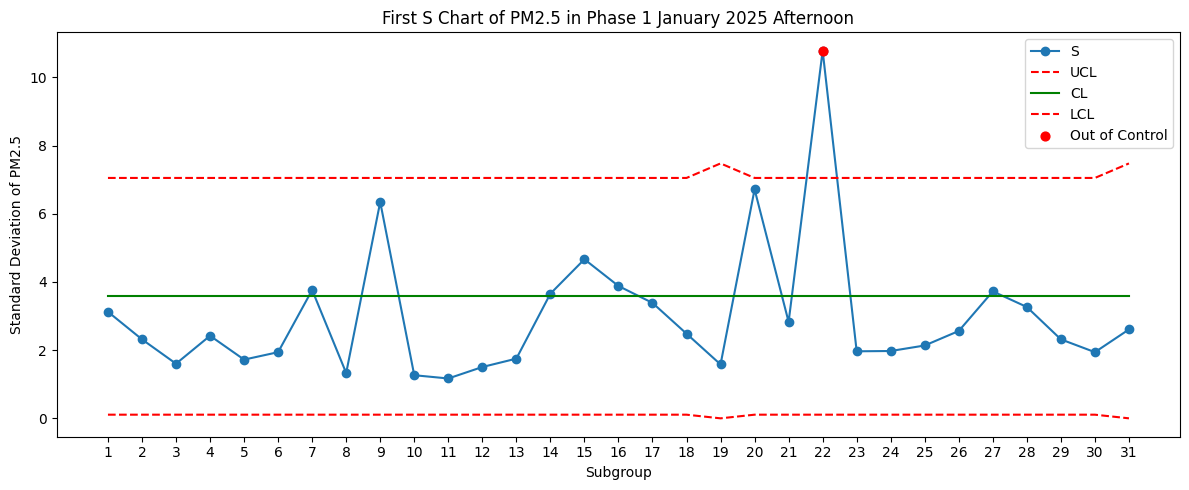

In [116]:
phase1_stats = s_limits(phase1_stats, s_bar)

# 建議先重設 index，讓圖上的 subgroup 從 0, 1, 2, ... 排列
phase1_stats = phase1_stats.reset_index(drop=True)

print("S chart out-of-control groups:")
print(
    phase1_stats.loc[
        phase1_stats["out_of_control_s"],
        ["date", "n", "s", "s_lcl", "s_cl", "s_ucl"]
    ]
)

plt.figure(figsize=(12, 5))

x = np.arange(1, len(phase1_stats) + 1)
# S value
plt.plot(
    x,
    phase1_stats["s"],
    marker="o",
    linestyle="-",
    label="S"
)

# UCL, CL, LCL
plt.plot(
    x,
    phase1_stats["s_ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase1_stats["s_cl"],
    color="green",
    linestyle="-",
    label="CL"
)

plt.plot(
    x,
    phase1_stats["s_lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

# 標出超出管制界限的點
out_mask = phase1_stats["out_of_control_s"]

plt.scatter(
    x[out_mask],
    phase1_stats.loc[out_mask, "s"],
    color="red",
    s=40,
    zorder=5,
    label="Out of Control"
)

plt.title("First S Chart of PM2.5 in Phase 1 January 2025 Afternoon")
plt.xlabel("Subgroup")
plt.ylabel("Standard Deviation of PM2.5")
plt.xticks(x)
plt.legend()

plt.tight_layout()
plt.show()

In [117]:
# 移除第一次 S chart 中 out-of-control 的 subgroup
phase1_clean = phase1_stats[~phase1_stats["out_of_control_s"]].copy()
phase1_clean = phase1_clean.reset_index(drop=True)

# 用清理後資料重新計算 S chart center line
m_clean = len(phase1_clean)

s_bar_clean = np.sqrt(
    ((phase1_clean["n"] - 1) * (phase1_clean["s"] ** 2)).sum()
    / (phase1_clean["n"].sum() - m_clean)
)

print("Clean S-bar =", s_bar_clean)

# 用清理後的 s_bar 重新計算 S chart limits
phase1_clean = s_limits(phase1_clean, s_bar_clean)

print("S chart out-of-control groups after cleaning:")
print(
    phase1_clean.loc[
        phase1_clean["out_of_control_s"],
        ["date", "n", "s", "s_lcl", "s_cl", "s_ucl"]
    ]
)

Clean S-bar = 3.052137044849156
S chart out-of-control groups after cleaning:
          date  n         s     s_lcl      s_cl    s_ucl
8   2025-01-09  6  6.345602  0.091564  3.052137  6.01271
19  2025-01-20  6  6.715653  0.091564  3.052137  6.01271


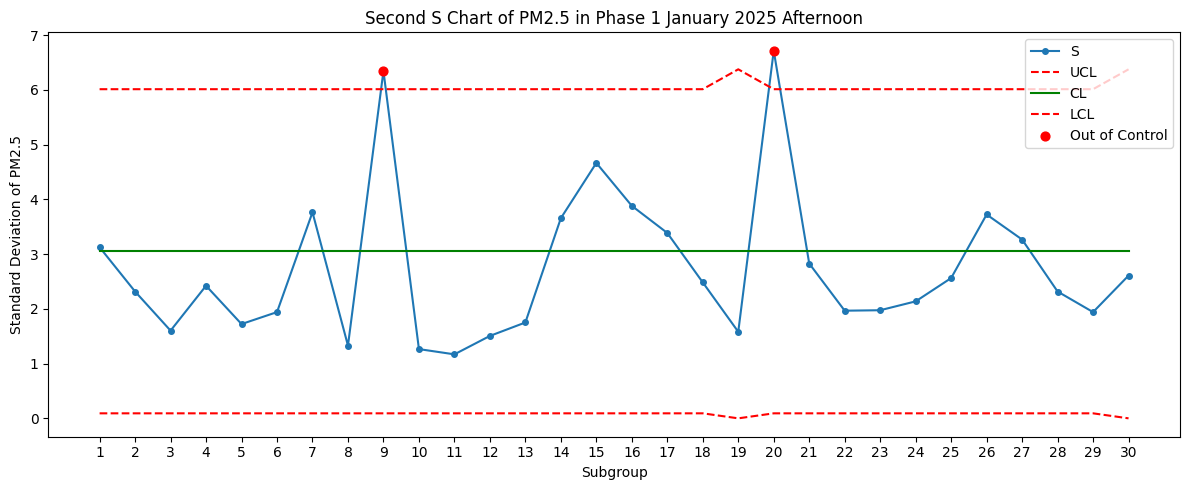

In [118]:
plt.figure(figsize=(12, 5))
x = np.arange(1, len(phase1_clean) + 1)
plt.plot(
    x,
    phase1_clean["s"],
    marker="o",
    markersize=4,
    linestyle="-",
    label="S"
)

plt.plot(
    x,
    phase1_clean["s_ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase1_clean["s_cl"],
    color="green",
    linestyle="-",
    label="CL"
)

plt.plot(
    x,
    phase1_clean["s_lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

out_mask_clean = phase1_clean["out_of_control_s"]

plt.scatter(
    x[out_mask_clean],
    phase1_clean.loc[out_mask_clean, "s"],
    color="red",
    s=40,
    zorder=5,
    label="Out of Control"
)

plt.title("Second S Chart of PM2.5 in Phase 1 January 2025 Afternoon")
plt.xlabel("Subgroup")
plt.ylabel("Standard Deviation of PM2.5")
plt.xticks(x)
plt.legend()

plt.tight_layout()
plt.show()

In [119]:
# 移除第二張 S chart 中 out-of-control 的 subgroup
phase1_clean2 = phase1_clean[~phase1_clean["out_of_control_s"]].copy()
phase1_clean2 = phase1_clean2.reset_index(drop=True)

# 用第二次清理後的資料重新計算 S chart center line
m_clean2 = len(phase1_clean2)

s_bar_clean2 = np.sqrt(
    ((phase1_clean2["n"] - 1) * (phase1_clean2["s"] ** 2)).sum()
    / (phase1_clean2["n"].sum() - m_clean2)
)

print("Second clean S-bar =", s_bar_clean2)

phase1_clean2 = s_limits(phase1_clean2, s_bar_clean2)

print("S chart out-of-control groups after second cleaning:")
print(
    phase1_clean2.loc[
        phase1_clean2["out_of_control_s"],
        ["date", "n", "s", "s_lcl", "s_cl", "s_ucl"]
    ]
)

Second clean S-bar = 2.626325292316777
S chart out-of-control groups after second cleaning:
Empty DataFrame
Columns: [date, n, s, s_lcl, s_cl, s_ucl]
Index: []


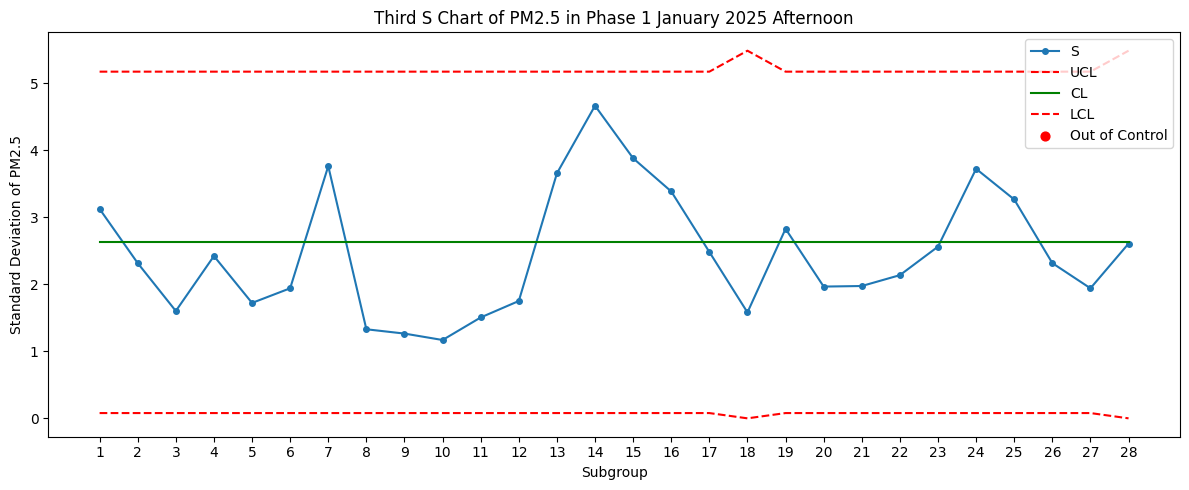

In [120]:
plt.figure(figsize=(12, 5))

x = np.arange(1, len(phase1_clean2) + 1)
plt.plot(
    x,
    phase1_clean2["s"],
    marker="o",
    markersize=4,
    linestyle="-",
    label="S"
)

plt.plot(
    x,
    phase1_clean2["s_ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase1_clean2["s_cl"],
    color="green",
    linestyle="-",
    label="CL"
)

plt.plot(
    x,
    phase1_clean2["s_lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

out_mask_clean2 = phase1_clean2["out_of_control_s"]

plt.scatter(
    x[out_mask_clean2],
    phase1_clean2.loc[out_mask_clean2, "s"],
    color="red",
    s=40,
    zorder=5,
    label="Out of Control"
)

plt.title("Third S Chart of PM2.5 in Phase 1 January 2025 Afternoon")
plt.xlabel("Subgroup")
plt.ylabel("Standard Deviation of PM2.5")
plt.xticks(x)
plt.legend()

plt.tight_layout()
plt.show()

In [132]:
s_chart_limits_summary = pd.DataFrame({
    "n": [5, 6],
    "B3": [0.000, 0.030],
    "B4": [2.089, 1.970],
    "CL": [s_bar, s_bar],
    "LCL": [0.000 * s_bar, 0.030 * s_bar],
    "UCL": [2.089 * s_bar, 1.970 * s_bar]
})

print(s_chart_limits_summary)

   n    B3     B4      CL       LCL       UCL
0  5  0.00  2.089  3.5792  0.000000  7.476950
1  6  0.03  1.970  3.5792  0.107376  7.051025


In [133]:
s_chart_limits_summary = pd.DataFrame({
    "n": [5, 6],
    "B3": [0.000, 0.030],
    "B4": [2.089, 1.970],
    "CL": [s_bar_clean, s_bar_clean],
    "LCL": [0.000 * s_bar_clean, 0.030 * s_bar_clean],
    "UCL": [2.089 * s_bar_clean, 1.970 * s_bar_clean]
})

print(s_chart_limits_summary)

   n    B3     B4        CL       LCL       UCL
0  5  0.00  2.089  3.052137  0.000000  6.375914
1  6  0.03  1.970  3.052137  0.091564  6.012710


In [134]:
s_chart_limits_summary = pd.DataFrame({
    "n": [5, 6],
    "B3": [0.000, 0.030],
    "B4": [2.089, 1.970],
    "CL": [s_bar_clean2, s_bar_clean2],
    "LCL": [0.000 * s_bar_clean2, 0.030 * s_bar_clean2],
    "UCL": [2.089 * s_bar_clean2, 1.970 * s_bar_clean2]
})

print(s_chart_limits_summary)

   n    B3     B4        CL      LCL       UCL
0  5  0.00  2.089  2.626325  0.00000  5.486394
1  6  0.03  1.970  2.626325  0.07879  5.173861


#### X bar chart

In [121]:
# X-bar chart center line
x_bar_bar = (
    (phase1_clean2["n"] * phase1_clean2["x_bar"]).sum()
    / phase1_clean2["n"].sum()
)

X-bar chart points above UCL:
          date  n      x_bar  xbar_lcl    xbar_cl   xbar_ucl
5   2025-01-06  6  20.833333  7.318715  10.698795  14.078876
12  2025-01-14  6  19.166667  7.318715  10.698795  14.078876
13  2025-01-15  6  28.166667  7.318715  10.698795  14.078876
18  2025-01-21  6  19.000000  7.318715  10.698795  14.078876


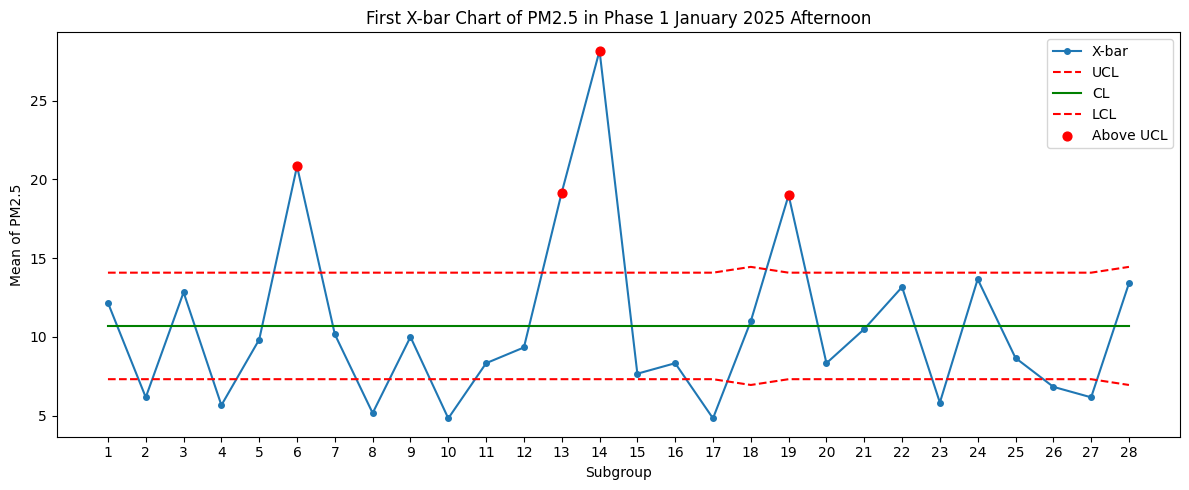

In [122]:
phase1_clean2 = xbar_limits(phase1_clean2, x_bar_bar, s_bar_clean2)

print("X-bar chart points above UCL:")
print(
    phase1_clean2.loc[
        phase1_clean2["out_of_control_xbar_high"],
        ["date", "n", "x_bar", "xbar_lcl", "xbar_cl", "xbar_ucl"]
    ]
)


plt.figure(figsize=(12, 5))


x = np.arange(1, len(phase1_clean2) + 1)

plt.plot(
    x,
    phase1_clean2["x_bar"],
    marker="o",
    markersize=4,
    linestyle="-",
    label="X-bar"
)

plt.plot(
    x,
    phase1_clean2["xbar_ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase1_clean2["xbar_cl"],
    color="green",
    linestyle="-",
    label="CL"
)

plt.plot(
    x,
    phase1_clean2["xbar_lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

out_mask_xbar_high = phase1_clean2["out_of_control_xbar_high"]

plt.scatter(
    x[out_mask_xbar_high],
    phase1_clean2.loc[out_mask_xbar_high, "x_bar"],
    color="red",
    s=40,
    zorder=5,
    label="Above UCL"
)

plt.title("First X-bar Chart of PM2.5 in Phase 1 January 2025 Afternoon")
plt.xlabel("Subgroup")
plt.ylabel("Mean of PM2.5")
plt.xticks(x)
plt.legend()

plt.tight_layout()
plt.show()

In [123]:
phase1_xbar_clean = phase1_clean2[
    ~phase1_clean2["out_of_control_xbar_high"]
].copy()

phase1_xbar_clean = phase1_xbar_clean.reset_index(drop=True)

m_clean3 = len(phase1_xbar_clean)

# X-bar chart center line
x_bar_bar_clean3 = (
    (phase1_xbar_clean["n"] * phase1_xbar_clean["x_bar"]).sum()
    / phase1_xbar_clean["n"].sum()
)

# Pooled standard deviation after removing high X-bar out-of-control points
s_bar_clean3 = np.sqrt(
    ((phase1_xbar_clean["n"] - 1) * (phase1_xbar_clean["s"] ** 2)).sum()
    / (phase1_xbar_clean["n"].sum() - m_clean3)
)

X-bar chart points above UCL:
          date  n      x_bar  xbar_lcl   xbar_cl   xbar_ucl
0   2025-01-01  6  12.166667  5.650666  8.823944  11.997222
2   2025-01-03  6  12.833333  5.650666  8.823944  11.997222
17  2025-01-25  6  13.166667  5.650666  8.823944  11.997222
19  2025-01-27  6  13.666667  5.650666  8.823944  11.997222
23  2025-01-31  5  13.400000  5.305476  8.823944  12.342411


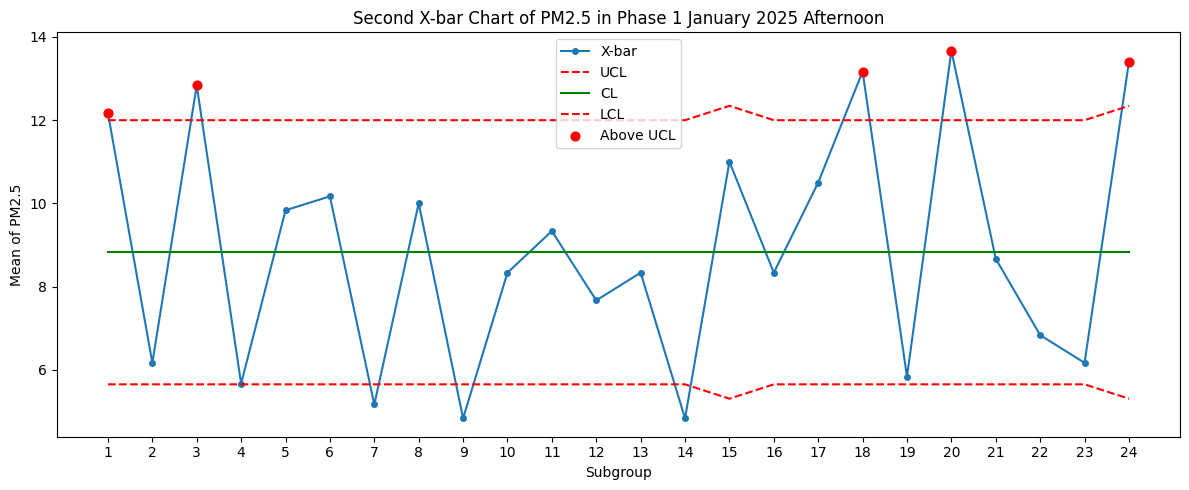

In [124]:
phase1_xbar_clean = xbar_limits(phase1_xbar_clean, x_bar_bar_clean3, s_bar_clean3)

print("X-bar chart points above UCL:")
print(
    phase1_xbar_clean.loc[
        phase1_xbar_clean["out_of_control_xbar_high"],
        ["date", "n", "x_bar", "xbar_lcl", "xbar_cl", "xbar_ucl"]
    ]
)

plt.figure(figsize=(12, 5))

x = np.arange(1, len(phase1_xbar_clean) + 1)
plt.plot(
    x,
    phase1_xbar_clean["x_bar"],
    marker="o",
    markersize=4,
    linestyle="-",
    label="X-bar"
)

plt.plot(
    x,
    phase1_xbar_clean["xbar_ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase1_xbar_clean["xbar_cl"],
    color="green",
    linestyle="-",
    label="CL"
)

plt.plot(
    x,
    phase1_xbar_clean["xbar_lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

out_mask_xbar_high = phase1_xbar_clean["out_of_control_xbar_high"]

plt.scatter(
    x[out_mask_xbar_high],
    phase1_xbar_clean.loc[out_mask_xbar_high, "x_bar"],
    color="red",
    s=40,
    zorder=5,
    label="Above UCL"
)

plt.title("Second X-bar Chart of PM2.5 in Phase 1 January 2025 Afternoon")
plt.xlabel("Subgroup")
plt.ylabel("Mean of PM2.5")
plt.xticks(x)
plt.legend()

plt.tight_layout()
plt.show()

In [125]:
phase1_xbar_clean2 = phase1_xbar_clean[
    ~phase1_xbar_clean["out_of_control_xbar_high"]
].copy()

phase1_xbar_clean2 = phase1_xbar_clean2.reset_index(drop=True)

m_clean4 = len(phase1_xbar_clean2)

# X-bar chart center line
x_bar_bar_clean4 = (
    (phase1_xbar_clean2["n"] * phase1_xbar_clean2["x_bar"]).sum()
    / phase1_xbar_clean2["n"].sum()
)

# Pooled standard deviation after removing high X-bar out-of-control points
s_bar_clean4 = np.sqrt(
    ((phase1_xbar_clean2["n"] - 1) * (phase1_xbar_clean2["s"] ** 2)).sum()
    / (phase1_xbar_clean2["n"].sum() - m_clean4)
)

X-bar chart points above UCL after second X-bar cleaning:
Empty DataFrame
Columns: [date, n, x_bar, xbar_lcl, xbar_cl, xbar_ucl]
Index: []


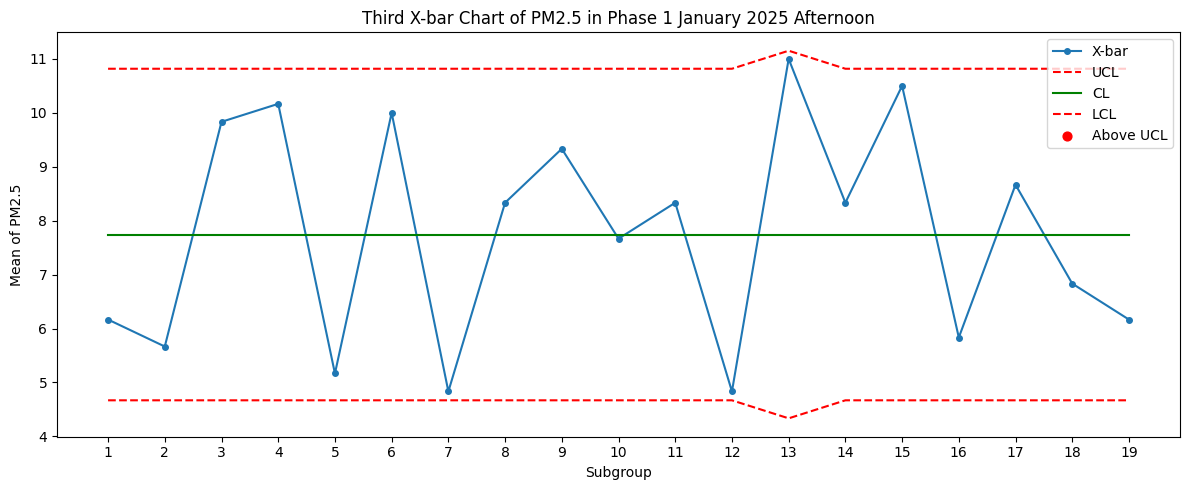

In [126]:
# 重新計算 X-bar chart limits
phase1_xbar_clean2 = xbar_limits(
    phase1_xbar_clean2,
    x_bar_bar_clean4,
    s_bar_clean4
)

print("X-bar chart points above UCL after second X-bar cleaning:")
print(
    phase1_xbar_clean2.loc[
        phase1_xbar_clean2["out_of_control_xbar_high"],
        ["date", "n", "x_bar", "xbar_lcl", "xbar_cl", "xbar_ucl"]
    ]
)


plt.figure(figsize=(12, 5))


x = np.arange(1, len(phase1_xbar_clean2) + 1)
plt.plot(
    x,
    phase1_xbar_clean2["x_bar"],
    marker="o",
    markersize=4,
    linestyle="-",
    label="X-bar"
)

plt.plot(
    x,
    phase1_xbar_clean2["xbar_ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase1_xbar_clean2["xbar_cl"],
    color="green",
    linestyle="-",
    label="CL"
)

plt.plot(
    x,
    phase1_xbar_clean2["xbar_lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

out_mask_xbar_high2 = phase1_xbar_clean2["out_of_control_xbar_high"]

plt.scatter(
    x[out_mask_xbar_high2],
    phase1_xbar_clean2.loc[out_mask_xbar_high2, "x_bar"],
    color="red",
    s=40,
    zorder=5,
    label="Above UCL"
)

plt.title("Third X-bar Chart of PM2.5 in Phase 1 January 2025 Afternoon")
plt.xlabel("Subgroup")
plt.ylabel("Mean of PM2.5")
plt.xticks(x)
plt.legend()

plt.tight_layout()
plt.show()

In [135]:

xbar_chart_limits_summary = pd.DataFrame({
    "n": [5, 6],
    "A3": [1.427, 1.287],
    "CL": [x_bar_bar, x_bar_bar],
    "LCL": [
        x_bar_bar - 1.427 * s_bar_clean2,
        x_bar_bar - 1.287 * s_bar_clean2
    ],
    "UCL": [
        x_bar_bar + 1.427 * s_bar_clean2,
        x_bar_bar + 1.287 * s_bar_clean2
    ]
})

print(xbar_chart_limits_summary.round(4))

   n     A3       CL     LCL      UCL
0  5  1.427  10.6988  6.9510  14.4466
1  6  1.287  10.6988  7.3187  14.0789


In [136]:

xbar_chart_limits_summary = pd.DataFrame({
    "n": [5, 6],
    "A3": [1.427, 1.287],
    "CL": [x_bar_bar_clean3, x_bar_bar_clean3],
    "LCL": [
        x_bar_bar_clean3 - 1.427 * s_bar_clean3,
        x_bar_bar_clean3 - 1.287 * s_bar_clean3
    ],
    "UCL": [
        x_bar_bar_clean3 + 1.427 * s_bar_clean3,
        x_bar_bar_clean3 + 1.287 * s_bar_clean3
    ]
})

print(xbar_chart_limits_summary.round(4))

   n     A3      CL     LCL      UCL
0  5  1.427  8.8239  5.3055  12.3424
1  6  1.287  8.8239  5.6507  11.9972


In [137]:

xbar_chart_limits_summary = pd.DataFrame({
    "n": [5, 6],
    "A3": [1.427, 1.287],
    "CL": [x_bar_bar_clean4, x_bar_bar_clean4],
    "LCL": [
        x_bar_bar_clean4 - 1.427 * s_bar_clean4,
        x_bar_bar_clean4 - 1.287 * s_bar_clean4
    ],
    "UCL": [
        x_bar_bar_clean4 + 1.427 * s_bar_clean4,
        x_bar_bar_clean4 + 1.287 * s_bar_clean4
    ]
})

print(xbar_chart_limits_summary.round(4))

   n     A3      CL     LCL      UCL
0  5  1.427  7.7434  4.3348  11.1520
1  6  1.287  7.7434  4.6692  10.8176


## Phase 2

In [127]:
# 使用 Phase 1 最終穩定 baseline 來監控 Phase 2
phase2 = phase2_stats.copy()
phase2 = phase2.reset_index(drop=True)

# 套用 Phase 1 最終的 X-bar chart limits
phase2_xbar = xbar_limits(
    phase2,
    x_bar_bar_clean4,
    s_bar_clean4
)

# 套用 Phase 1 最終的 S chart limits
phase2_s = s_limits(
    phase2,
    s_bar_clean4
)


In [128]:

print("Phase 2 X-bar points above UCL:")
print(
    phase2_xbar.loc[
        phase2_xbar["out_of_control_xbar_high"],
        ["date", "n", "x_bar", "xbar_lcl", "xbar_cl", "xbar_ucl"]
    ]
)

print(
    "Phase 2 X-bar points above UCL count =",
    phase2_xbar["out_of_control_xbar_high"].sum()
)

Phase 2 X-bar points above UCL:
          date  n      x_bar  xbar_lcl   xbar_cl   xbar_ucl
1   2026-01-02  6  13.833333  4.669164  7.743363  10.817562
3   2026-01-04  6  12.500000  4.669164  7.743363  10.817562
4   2026-01-05  6  16.333333  4.669164  7.743363  10.817562
5   2026-01-06  6  37.000000  4.669164  7.743363  10.817562
6   2026-01-07  6  22.500000  4.669164  7.743363  10.817562
7   2026-01-08  6  19.500000  4.669164  7.743363  10.817562
8   2026-01-09  6  15.166667  4.669164  7.743363  10.817562
10  2026-01-11  6  21.333333  4.669164  7.743363  10.817562
11  2026-01-12  6  19.666667  4.669164  7.743363  10.817562
12  2026-01-13  5  19.200000  4.334752  7.743363  11.151974
13  2026-01-14  6  12.666667  4.669164  7.743363  10.817562
14  2026-01-15  6  15.833333  4.669164  7.743363  10.817562
15  2026-01-16  6  20.500000  4.669164  7.743363  10.817562
16  2026-01-17  6  16.500000  4.669164  7.743363  10.817562
17  2026-01-18  6  17.333333  4.669164  7.743363  10.817562
18  2026

In [129]:
print("Phase 2 S chart out-of-control groups:")
print(
    phase2_s.loc[
        phase2_s["out_of_control_s"],
        ["date", "n", "s", "s_lcl", "s_cl", "s_ucl"]
    ]
)

print(
    "Phase 2 S chart out-of-control count =",
    phase2_s["out_of_control_s"].sum()
)

Phase 2 S chart out-of-control groups:
         date  n         s    s_lcl      s_cl     s_ucl
3  2026-01-04  6  4.929503  0.07166  2.388655  4.705651
Phase 2 S chart out-of-control count = 1


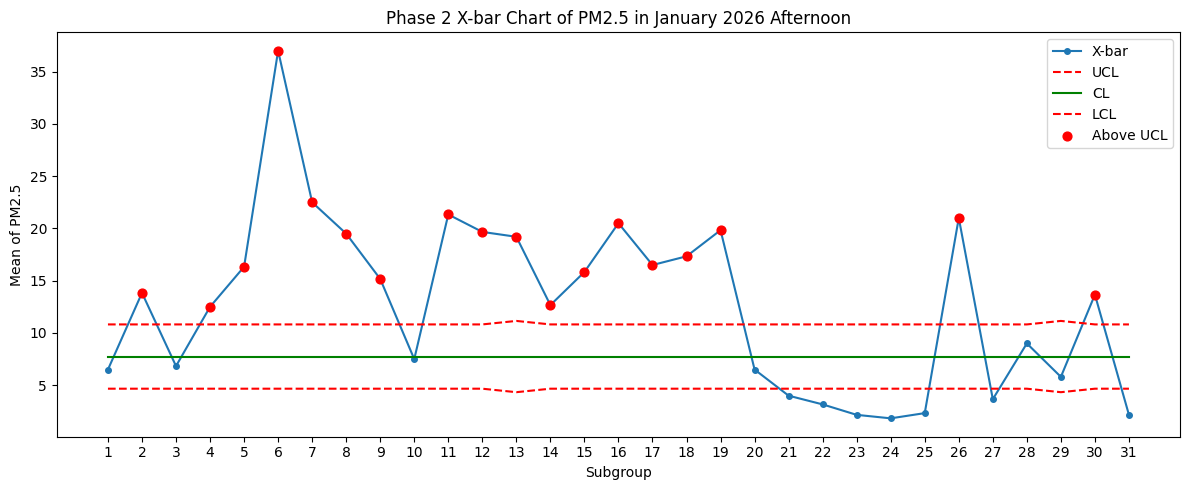

In [130]:
plt.figure(figsize=(12, 5))

# 從 1 開始當 subgroup 編號
x = np.arange(1, len(phase2_xbar) + 1)

plt.plot(
    x,
    phase2_xbar["x_bar"],
    marker="o",
    markersize=4,
    linestyle="-",
    label="X-bar"
)

plt.plot(
    x,
    phase2_xbar["xbar_ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase2_xbar["xbar_cl"],
    color="green",
    linestyle="-",
    label="CL"
)

plt.plot(
    x,
    phase2_xbar["xbar_lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

out_mask_phase2_high = phase2_xbar["out_of_control_xbar_high"]

plt.scatter(
    x[out_mask_phase2_high],
    phase2_xbar.loc[out_mask_phase2_high, "x_bar"],
    color="red",
    s=40,
    zorder=5,
    label="Above UCL"
)

plt.title("Phase 2 X-bar Chart of PM2.5 in January 2026 Afternoon")
plt.xlabel("Subgroup")
plt.ylabel("Mean of PM2.5")
plt.xticks(x)
plt.legend()

plt.tight_layout()
plt.show()

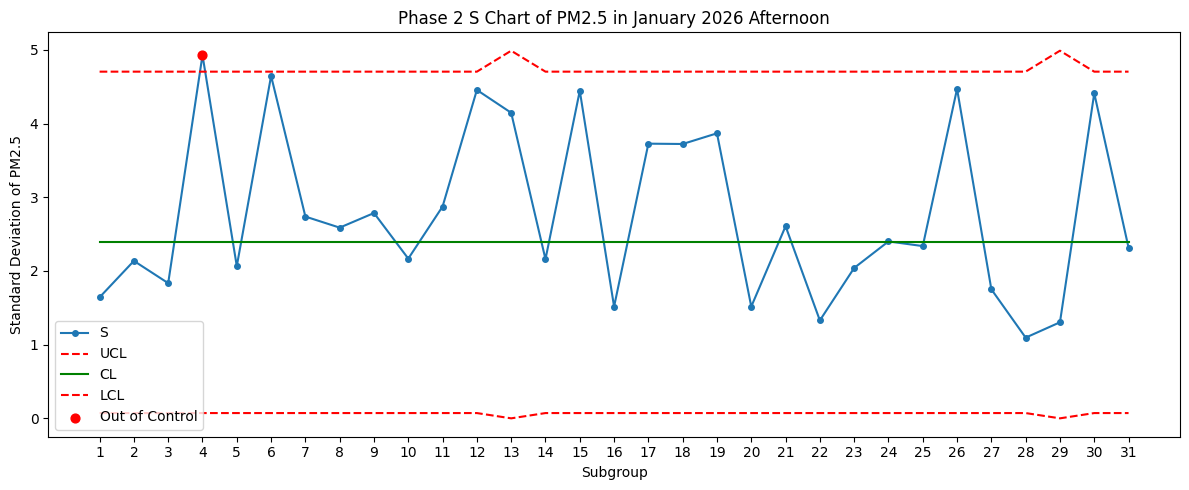

In [131]:
plt.figure(figsize=(12, 5))

# 從 1 開始當 subgroup 編號
x = np.arange(1, len(phase2_s) + 1)

plt.plot(
    x,
    phase2_s["s"],
    marker="o",
    markersize=4,
    linestyle="-",
    label="S"
)

plt.plot(
    x,
    phase2_s["s_ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase2_s["s_cl"],
    color="green",
    linestyle="-",
    label="CL"
)

plt.plot(
    x,
    phase2_s["s_lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

out_mask_phase2_s = phase2_s["out_of_control_s"]

plt.scatter(
    x[out_mask_phase2_s],
    phase2_s.loc[out_mask_phase2_s, "s"],
    color="red",
    s=40,
    zorder=5,
    label="Out of Control"
)

plt.title("Phase 2 S Chart of PM2.5 in January 2026 Afternoon")
plt.xlabel("Subgroup")
plt.ylabel("Standard Deviation of PM2.5")
plt.xticks(x)
plt.legend()

plt.tight_layout()
plt.show()

In [138]:
s_chart_limits_summary = pd.DataFrame({
    "n": [5, 6],
    "B3": [0.000, 0.030],
    "B4": [2.089, 1.970],
    "CL": [s_bar_clean4, s_bar_clean4],
    "LCL": [0.000 * s_bar_clean4, 0.030 * s_bar_clean4],
    "UCL": [2.089 * s_bar_clean4, 1.970 * s_bar_clean4]
})

print(s_chart_limits_summary)

   n    B3     B4        CL      LCL       UCL
0  5  0.00  2.089  2.388655  0.00000  4.989901
1  6  0.03  1.970  2.388655  0.07166  4.705651
